---
# All curves

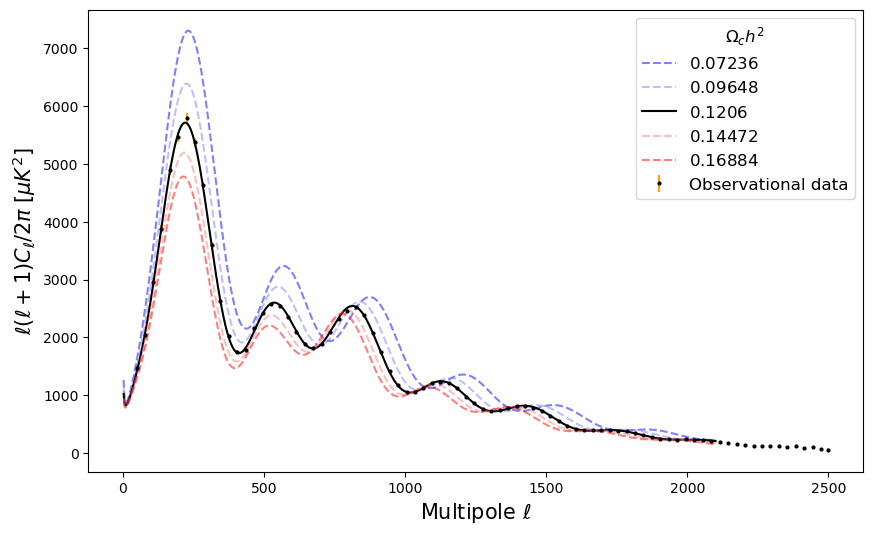

In [1]:
from config import DATA_PATH, RESULTS_PATH
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors

# Parameter values
params = [0.07236, 0.09648, 0.1206,  0.14472, 0.16884]

# Color normalization and colormap
cmap = plt.get_cmap('bwr')
norm = colors.Normalize(vmin=params[0], vmax=params[-1])

# Load observational points
binned = np.loadtxt(DATA_PATH / 'binned.txt')
x_b = binned[:,0]
y_b = binned[:,1]
yerr1 = binned[:,2]
yerr2 = binned[:,3]
err = np.array([yerr1,yerr2])

# Load data for ALL parameters at once, then access it sequentially
all_data = {
    p: np.loadtxt(DATA_PATH / f'OMEGA_C/oc{p}.txt')
    for p in params
}

# Create the canvas and plot observational points
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(x_b, y_b, yerr=err, fmt='o', markersize=2, ecolor='orange', c='k', label='Observational data')

for i, p in enumerate(params): # Loop through parameter values and plot the curves
    
    color = cmap(norm(p))
    
    data = all_data[p]
    x = data[:,0]
    y = data[:,1]
    
    # To make the optimal value stand out, we draw it differently inside the else statement
    if i!=2:
        ax.plot(x, y, alpha=0.5, c=color, ls='--', label=f'${p}$')
        
    else:
        ax.plot(x, y, c='k', label=f'${p}$')

# Axes labels and legend
ax.set_xlabel("Multipole $\ell$", fontsize=15)
ax.set_ylabel('$\ell(\ell+1)C_{\ell}/2 \pi \ [\mu K^2]$', fontsize=15)
plt.legend(fontsize=12, title=r'$\Omega_c h^2$', title_fontsize=12)

# Save image to memory       
fig.savefig(RESULTS_PATH / f'OMEGA_C/oc_todas.pdf', format='pdf', bbox_inches='tight')

---
# Animation

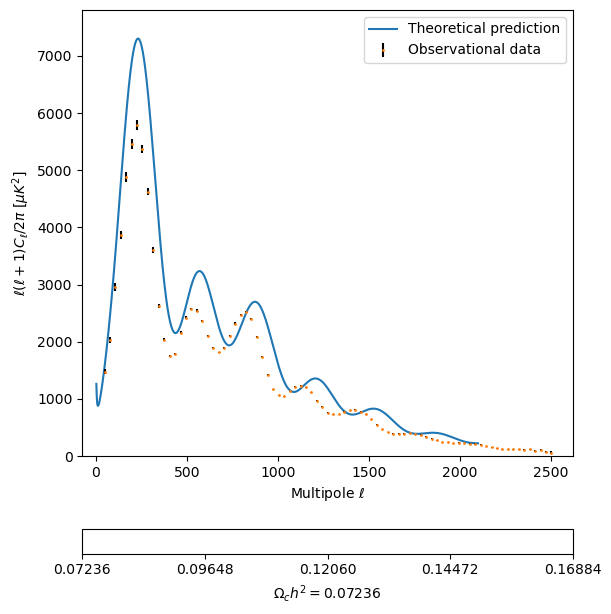

In [2]:
from config import DATA_PATH, RESULTS_PATH
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.animation import FuncAnimation

# Parameter values
params = [0.07236, 0.09648, 0.1206,  0.14472, 0.16884]

# Load observational points
binned = np.loadtxt(DATA_PATH / 'binned.txt')
x_b = binned[:,0]
y_b = binned[:,1]
yerr1 = binned[:,2]
yerr2 = binned[:,3]
err = np.array([yerr1,yerr2])

# Load data for ALL parameters at once, then access it sequentially
all_data = {
    p: np.loadtxt(DATA_PATH / f'OMEGA_C/oc{p}.txt')
    for p in params
}

# Create the canvas and an empty curve, which will be updated at each step of the animation
fig, ax = plt.subplots(figsize=(6,6), constrained_layout=True)
line = ax.plot([], [], label='Theoretical prediction')

# Some canvas configuration and observational points
ymax = max([np.max(item[:,1]) for item in all_data.values()])
ax.set(xlabel="Multipole $\ell$", ylabel="$\ell(\ell+1)C_{\ell}/2 \pi \ [\mu K^2]$", ylim=[0, ymax + 500])
ax.errorbar(x_b, y_b, yerr=err, fmt='o', markersize=1, ecolor='k', label='Observational data')
ax.legend()

# Create a blank colorbar, to be updated later
colors_list = ['white'] * len(params)
cmap = mpl.colors.ListedColormap(colors_list)
norm = mpl.colors.BoundaryNorm(params, cmap.N)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

cbar = fig.colorbar(sm, orientation='horizontal', label=f"$\Omega_c h^2={params[0]}$", ax=ax)

def update(i): # Update function for the animation
    
    # Update parameter value
    p = params[i]
    
    # Update colorbar
    colors_list = ['red'] * i + ['white'] * (len(params) - 1 - i)
    cmap = mpl.colors.ListedColormap(colors_list)
    sm.set_cmap(cmap)
    cbar.set_label(f'$\Omega_c h^2={p}$')
    
    # Set data to be plotted
    data = all_data[p]
    x = data[:,0]
    y = data[:,1]
    
    # Update curve
    line[0].set_data(x, y)

    return line,

# Generate animation and save to memory
animation = FuncAnimation(fig, update, len(params))
animation.save(RESULTS_PATH / 'OMEGA_C/animation.gif', fps=1.5, writer='pillow')